Valid trajectories: 84
Best:     4.875s  r1=170.2m  r2=173.1m
Baseline: 5.083s
Worst:    5.284s
Saved.

                              WORST   BASELINE       BEST
                C1.x (m)    -298.32    -300.84    -301.62
                C1.y (m)    -363.48    -349.27    -284.30
                C2.x (m)    -319.98    -320.65    -302.08
                C2.y (m)    -273.26    -266.73    -281.38
        Radius arc 1 (m)      99.90     110.67     170.15
        Radius arc 2 (m)     192.68     195.56     173.11
      Speed arc 1 (km/h)     151.20     159.14     197.33
      Speed arc 2 (km/h)     209.98     211.55     199.04
        Arc 1 length (m)      83.40      82.29      80.67
        Arc 2 length (m)     192.38     189.31     188.18
          Total time (s)       5.28       5.08       4.88

Best trajectory circle centers + junction angles:
  Arc 1: C1 = (-301.62, -284.30)  r1 = 170.15 m
  Arc 2: C2 = (-302.08, -281.38)  r2 = 173.11 m

  WORST:
    Arc 1 (C1): entry @ -2.1700 rad  →  jun

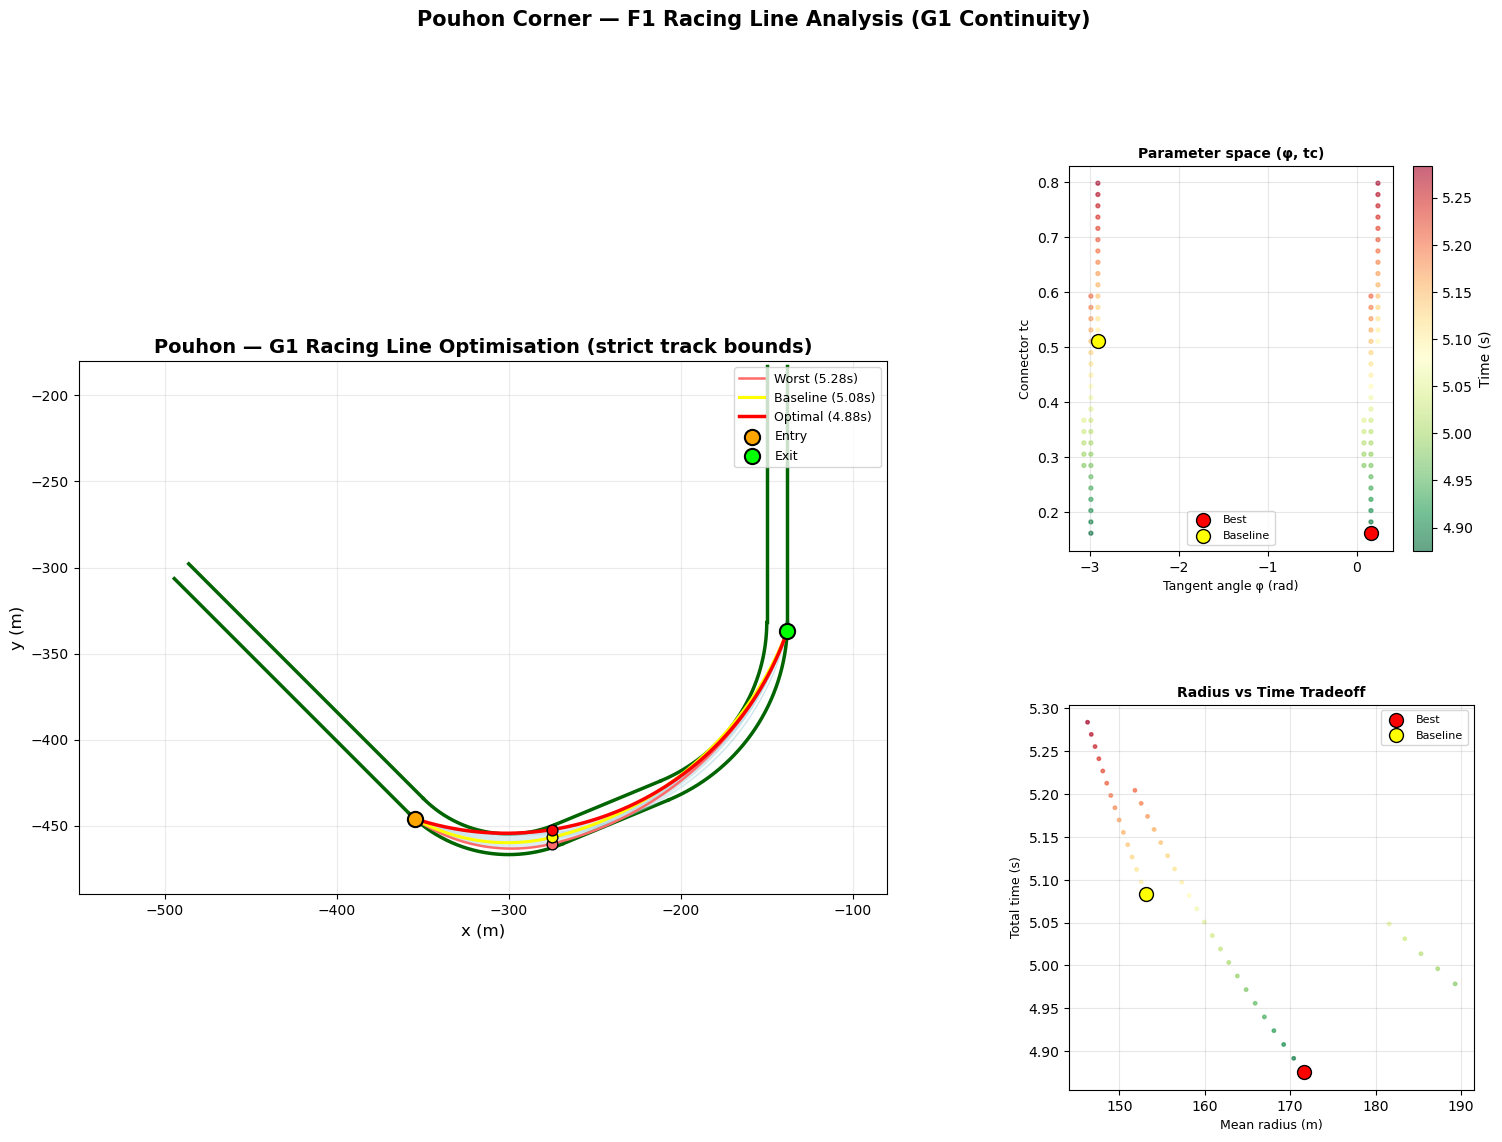

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

MU, G   = 1.8, 9.81
slope   = np.tan(np.radians(22.5))
cot22   = 1/np.tan(np.radians(22.5))
c_inner = -336.35
c_outer = -(336.35 + 12/np.cos(np.radians(22.5)))

entry = np.array([-354.66401, -445.97157])
exit_ = np.array([-138.12432, -336.92555])

def connector_point(tc):
    c = c_inner*(1-tc) + c_outer*tc
    return np.array([-275.0, slope*-275.0 + c])

# ── Strict track boundary (no padding) ───────────────────────────────────────
def inside_track(x, y):
    in_s1  = ((-x-800.8 <= y <= -x-800.8+12*np.sqrt(2)) and
               (y < x+188.5) and (y > x+300-384.85))
    d1     = np.sqrt((x+300)**2+(y+384.85)**2)
    in_a1  = ((70 - 0.5 <= d1 <= 82 + 0.5) and
               (y < x+300-384.85) and (y+384.85 < -cot22*(x+300)))
    y_in   = slope*x-336.35
    y_out  = slope*x-336.35-12/np.cos(np.radians(22.5))
    in_mid = ((y_out <= y <= y_in) and
               (y+331.65 < -cot22*(x+250)) and (y+384.85 > -cot22*(x+300)))
    d2     = np.sqrt((x+250)**2+(y+331.65)**2)
    in_a2  = ((100 - 0.5 <= d2 <= 112 + 0.5) and
               (y < -331.65) and (y+331.65 > -cot22*(x+250)))
    in_ex  = ((-150 <= x <= -138) and (-331.65 >= y >= -182.62))
    return in_s1 or in_a1 or in_mid or in_a2 or in_ex

def arc_in_track(xs, ys, step=4):
    """All sampled arc points must lie inside the strict track boundary."""
    for x, y in zip(xs[::step], ys[::step]):
        if not inside_track(x, y):
            return False
    return True

# ── G1 circle ─────────────────────────────────────────────────────────────────
def circle_g1(P, J, T):
    N = np.array([-T[1], T[0]])
    d = J - P
    denom = 2*np.dot(d, N)
    if abs(denom) < 1e-8: return None
    r = -np.dot(d,d)/denom
    return J + r*N, r

def arc_stats(P, J, C, r):
    r = abs(r)
    if r < 1e-3: return None
    t1  = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2  = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt  = (t2-t1+np.pi)%(2*np.pi)-np.pi
    arc = r*abs(dt)
    return arc/np.sqrt(MU*G*r), arc, r, abs(np.degrees(dt))

def arc_pts(P, J, C, r, n=400):
    r  = abs(r)
    t1 = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2 = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt = (t2-t1+np.pi)%(2*np.pi)-np.pi
    a  = np.linspace(t1, t1+dt, n)
    return C[0]+r*np.cos(a), C[1]+r*np.sin(a)

# ── Optimization ──────────────────────────────────────────────────────────────
N_TC, N_PHI = 40, 80
tc_vals  = np.linspace(0.1, 0.9, N_TC)
phi_vals = np.linspace(-np.pi, np.pi, N_PHI, endpoint=False)

results = []
for tc in tc_vals:
    J = connector_point(tc)
    for phi in phi_vals:
        T = np.array([np.cos(phi), np.sin(phi)])

        r1 = circle_g1(entry, J,  T)
        if r1 is None: continue
        C1, rv1 = r1
        s1 = arc_stats(entry, J, C1, rv1)
        if s1 is None: continue
        t1, l1, r1a, deg1 = s1

        r2 = circle_g1(exit_, J, -T)
        if r2 is None: continue
        C2, rv2 = r2
        s2 = arc_stats(J, exit_, C2, rv2)
        if s2 is None: continue
        t2, l2, r2a, deg2 = s2

        if r1a > 400 or r2a > 400: continue
        if r1a < 10  or r2a < 10:  continue
        if deg1 > 120 or deg2 > 120: continue

        p1 = arc_pts(entry, J,     C1, r1a)
        p2 = arc_pts(J,     exit_, C2, r2a)

        # Strict boundary check on both arcs
        if not arc_in_track(p1[0], p1[1]): continue
        if not arc_in_track(p2[0], p2[1]): continue

        results.append(dict(
            tc=tc, phi=phi, J=J.copy(),
            C1=C1, r1=r1a, l1=l1, deg1=deg1, t1=t1,
            C2=C2, r2=r2a, l2=l2, deg2=deg2, t2=t2,
            time=t1+t2,
            v1=np.sqrt(MU*G*r1a)*3.6,
            v2=np.sqrt(MU*G*r2a)*3.6,
        ))

results.sort(key=lambda x: x['time'])
print(f"Valid trajectories: {len(results)}")
if not results:
    exit("No valid trajectories found.")

best     = results[0]
worst    = results[-1]
baseline = min(results, key=lambda r: (r['tc']-0.5)**2)

print(f"Best:     {best['time']:.3f}s  r1={best['r1']:.1f}m  r2={best['r2']:.1f}m")
print(f"Baseline: {baseline['time']:.3f}s")
print(f"Worst:    {worst['time']:.3f}s")

# ── Track drawing ─────────────────────────────────────────────────────────────
def draw_track(ax):
    theta = np.linspace(0,2*np.pi,2000)
    x1 = np.linspace(-600,200,2000)
    y=-x1-800.8;              m=(y<x1+188.5)&(y>x1+300-384.85);  ax.plot(x1[m],y[m],'darkgreen',lw=2.5)
    y=-x1-800.8+12*np.sqrt(2);m=(y<x1+188.5)&(y>x1-84.85);       ax.plot(x1[m],y[m],'darkgreen',lw=2.5)
    xc=-300+70*np.cos(theta); yc=-384.85+70*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));             ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    xc=-300+82*np.cos(theta); yc=-384.85+82*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));             ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    xt=np.linspace(-600,200,2000)
    yt=slope*xt-336.35;        m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300)); ax.plot(xt[m],yt[m],'darkgreen',lw=2.5)
    yt=slope*xt-336.35-12/np.cos(np.radians(22.5))
    m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300));    ax.plot(xt[m],yt[m],'darkgreen',lw=2.5)
    xc=-250+100*np.cos(theta); yc=-331.65+100*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                   ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    xc=-250+112*np.cos(theta); yc=-331.65+112*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                   ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    yv=np.linspace(-500,-150,1000); mv=(yv>-331.65)&(yv<-182.62)
    ax.plot(np.full_like(yv[mv],-150),yv[mv],'darkgreen',lw=2.5)
    ax.plot(np.full_like(yv[mv],-138),yv[mv],'darkgreen',lw=2.5)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18,12))
gs  = GridSpec(2,2,figure=fig,width_ratios=[2,1],hspace=0.4,wspace=0.3)
ax_track    = fig.add_subplot(gs[:,0])
ax_scatter  = fig.add_subplot(gs[0,1])
ax_tradeoff = fig.add_subplot(gs[1,1])

draw_track(ax_track)

step = max(1,len(results)//500)
for res in results[::step]:
    p1 = arc_pts(entry,    res['J'], res['C1'], res['r1'])
    p2 = arc_pts(res['J'], exit_,   res['C2'], res['r2'])
    ax_track.plot(p1[0],p1[1],color='lightblue',alpha=0.15,lw=0.5)
    ax_track.plot(p2[0],p2[1],color='lightblue',alpha=0.15,lw=0.5)

for res,col,lw,lab,zo in [
    (worst,   '#ff6b6b',1.8,'Worst',   8),
    (baseline,'yellow', 2.2,'Baseline',9),
    (best,    'red',    2.5,'Optimal', 10),
]:
    p1 = arc_pts(entry,    res['J'], res['C1'], res['r1'])
    p2 = arc_pts(res['J'], exit_,   res['C2'], res['r2'])
    ax_track.plot(p1[0],p1[1],color=col,lw=lw,label=f"{lab} ({res['time']:.2f}s)",zorder=zo)
    ax_track.plot(p2[0],p2[1],color=col,lw=lw,zorder=zo)
    ax_track.scatter(*res['J'],color=col,s=60,zorder=zo+1,edgecolors='black',lw=1)

ax_track.scatter(*entry,color='orange',s=120,zorder=15,edgecolors='black',lw=1.5,label='Entry')
ax_track.scatter(*exit_, color='lime', s=120,zorder=15,edgecolors='black',lw=1.5,label='Exit')
ax_track.set_aspect('equal'); ax_track.set_xlim(-550,-80); ax_track.set_ylim(-490,-180)
ax_track.grid(True,alpha=0.25); ax_track.set_xlabel('x (m)',fontsize=12); ax_track.set_ylabel('y (m)',fontsize=12)
ax_track.set_title('Pouhon — G1 Racing Line Optimisation (strict track bounds)',fontsize=14,fontweight='bold')
ax_track.legend(loc='upper right',fontsize=9)

times=np.array([r['time'] for r in results])
phis =np.array([r['phi']  for r in results])
tcs  =np.array([r['tc']   for r in results])
sc=ax_scatter.scatter(phis,tcs,c=times,cmap='RdYlGn_r',s=8,alpha=0.6)
plt.colorbar(sc,ax=ax_scatter,label='Time (s)')
ax_scatter.scatter(best['phi'],    best['tc'],    color='red',   s=100,zorder=5,edgecolors='black',label='Best')
ax_scatter.scatter(baseline['phi'],baseline['tc'],color='yellow',s=100,zorder=5,edgecolors='black',label='Baseline')
ax_scatter.set_xlabel('Tangent angle φ (rad)',fontsize=9); ax_scatter.set_ylabel('Connector tc',fontsize=9)
ax_scatter.set_title('Parameter space (φ, tc)',fontsize=10,fontweight='bold')
ax_scatter.legend(fontsize=8); ax_scatter.grid(True,alpha=0.3)

r_avg=np.array([(r['r1']+r['r2'])/2 for r in results])
ax_tradeoff.scatter(r_avg,times,c=times,cmap='RdYlGn_r',s=6,alpha=0.4)
ax_tradeoff.scatter((best['r1']+best['r2'])/2,    best['time'],    color='red',   s=100,zorder=5,edgecolors='black',label='Best')
ax_tradeoff.scatter((baseline['r1']+baseline['r2'])/2,baseline['time'],color='yellow',s=100,zorder=5,edgecolors='black',label='Baseline')
ax_tradeoff.set_xlabel('Mean radius (m)',fontsize=9); ax_tradeoff.set_ylabel('Total time (s)',fontsize=9)
ax_tradeoff.set_title('Radius vs Time Tradeoff',fontsize=10,fontweight='bold')
ax_tradeoff.legend(fontsize=8); ax_tradeoff.grid(True,alpha=0.3)

plt.suptitle('Pouhon Corner — F1 Racing Line Analysis (G1 Continuity)',fontsize=15,fontweight='bold',y=1.01)
# plt.savefig('/mnt/user-data/outputs/pouhon_g1.png',dpi=150,bbox_inches='tight')
print("Saved.")
print()
print(f"{'':>24} {'WORST':>10} {'BASELINE':>10} {'BEST':>10}")
print("="*60)
print(f"{'C1.x (m)':>24} {worst['C1'][0]:>10.2f} {baseline['C1'][0]:>10.2f} {best['C1'][0]:>10.2f}")
print(f"{'C1.y (m)':>24} {worst['C1'][1]:>10.2f} {baseline['C1'][1]:>10.2f} {best['C1'][1]:>10.2f}")
print(f"{'C2.x (m)':>24} {worst['C2'][0]:>10.2f} {baseline['C2'][0]:>10.2f} {best['C2'][0]:>10.2f}")
print(f"{'C2.y (m)':>24} {worst['C2'][1]:>10.2f} {baseline['C2'][1]:>10.2f} {best['C2'][1]:>10.2f}")
for label,key in [
    ('Radius arc 1 (m)','r1'),('Radius arc 2 (m)','r2'),
    ('Speed arc 1 (km/h)','v1'),('Speed arc 2 (km/h)','v2'),
    ('Arc 1 length (m)','l1'),('Arc 2 length (m)','l2'),
    ('Total time (s)','time'),
]:
    print(f"{label:>24} {worst[key]:>10.2f} {baseline[key]:>10.2f} {best[key]:>10.2f}")

print(f"\nBest trajectory circle centers + junction angles:")
print(f"  Arc 1: C1 = ({best['C1'][0]:.2f}, {best['C1'][1]:.2f})  r1 = {best['r1']:.2f} m")
print(f"  Arc 2: C2 = ({best['C2'][0]:.2f}, {best['C2'][1]:.2f})  r2 = {best['r2']:.2f} m")

for label, res in [('WORST', worst), ('BASELINE', baseline), ('BEST', best)]:
    J = res['J']
    angle_J_from_C1     = np.arctan2(J[1]      - res['C1'][1], J[0]      - res['C1'][0])
    angle_J_from_C2     = np.arctan2(J[1]      - res['C2'][1], J[0]      - res['C2'][0])
    angle_entry_from_C1 = np.arctan2(entry[1]  - res['C1'][1], entry[0]  - res['C1'][0])
    angle_exit_from_C2  = np.arctan2(exit_[1]  - res['C2'][1], exit_[0]  - res['C2'][0])
    deg1_rad = np.radians(res['deg1'])
    deg2_rad = np.radians(res['deg2'])
    print(f"\n  {label}:")
    print(f"    Arc 1 (C1): entry @ {angle_entry_from_C1:.4f} rad  →  junction @ {angle_J_from_C1:.4f} rad  (sweep {deg1_rad:.4f} rad)")
    print(f"    Arc 2 (C2): junction @ {angle_J_from_C2:.4f} rad  →  exit    @ {angle_exit_from_C2:.4f} rad  (sweep {deg2_rad:.4f} rad)")

In [7]:
def arc_to_cubic_bezier(C, r, t_start, t_end):
    """
    Approximate a circular arc as a cubic Bezier curve.
    Returns P0, P1, P2, P3 (control points).
    Uses the standard alpha = 4/3 * tan(dt/4) formula.
    """
    dt = t_end - t_start
    alpha = (4/3) * np.tan(dt / 4)

    # Start and end points on the circle
    P0 = C + r * np.array([np.cos(t_start), np.sin(t_start)])
    P3 = C + r * np.array([np.cos(t_end),   np.sin(t_end)])

    # Tangent directions at start and end
    T0 = np.array([-np.sin(t_start), np.cos(t_start)])
    T3 = np.array([-np.sin(t_end),   np.cos(t_end)])

    # Control points
    P1 = P0 + alpha * r * T0
    P2 = P3 - alpha * r * T3

    return P0, P1, P2, P3


for label, res in [ ('BEST', best)]:
    J = res['J']

    t_entry = np.arctan2(entry[1] - res['C1'][1], entry[0] - res['C1'][0])
    t_J1    = np.arctan2(J[1]     - res['C1'][1], J[0]     - res['C1'][0])
    t_J2    = np.arctan2(J[1]     - res['C2'][1], J[0]     - res['C2'][0])
    t_exit  = np.arctan2(exit_[1] - res['C2'][1], exit_[0] - res['C2'][0])

    # Recover signed sweep (same logic as arc_stats)
    dt1 = (t_J1 - t_entry + np.pi) % (2*np.pi) - np.pi
    dt2 = (t_exit - t_J2  + np.pi) % (2*np.pi) - np.pi

    P0_1, P1_1, P2_1, P3_1 = arc_to_cubic_bezier(res['C1'], res['r1'], t_entry, t_entry + dt1)
    P0_2, P1_2, P2_2, P3_2 = arc_to_cubic_bezier(res['C2'], res['r2'], t_J2,    t_J2    + dt2)

    print(f"\n{'='*60}")
    print(f"  {label} — Cubic Bezier control points")
    print(f"  Arc 1 (entry → junction):")
    print(f"    P0 = ({P0_1[0]:.4f}, {P0_1[1]:.4f})  [on circle, = entry]")
    print(f"    P1 = ({P1_1[0]:.4f}, {P1_1[1]:.4f})  [control]")
    print(f"    P2 = ({P2_1[0]:.4f}, {P2_1[1]:.4f})  [control]")
    print(f"    P3 = ({P3_1[0]:.4f}, {P3_1[1]:.4f})  [on circle, = junction]")
    print(f"  Arc 2 (junction → exit):")
    print(f"    P0 = ({P0_2[0]:.4f}, {P0_2[1]:.4f})  [on circle, = junction]")
    print(f"    P1 = ({P1_2[0]:.4f}, {P1_2[1]:.4f})  [control]")
    print(f"    P2 = ({P2_2[0]:.4f}, {P2_2[1]:.4f})  [control]")
    print(f"    P3 = ({P3_2[0]:.4f}, {P3_2[1]:.4f})  [on circle, = exit]")
    print(f"  alpha1 = {(4/3)*np.tan(dt1/4):.6f}  (sweep {dt1:.4f} rad)")
    print(f"  alpha2 = {(4/3)*np.tan(dt2/4):.6f}  (sweep {dt2:.4f} rad)")


  BEST — Cubic Bezier control points
  Arc 1 (entry → junction):
    P0 = (-354.6640, -445.9716)  [on circle, = entry]
    P1 = (-328.9929, -454.3946)  [control]
    P2 = (-301.6850, -456.5834)  [control]
    P3 = (-275.0000, -452.3569)  [on circle, = junction]
  Arc 2 (junction → exit):
    P0 = (-275.0000, -452.3569)  [on circle, = junction]
    P1 = (-211.4736, -442.2953)  [control]
    P2 = (-158.7627, -397.8426)  [control]
    P3 = (-138.1243, -336.9255)  [on circle, = exit]
  alpha1 = 0.158786  (sweep 0.4741 rad)
  alpha2 = 0.371545  (sweep 1.0871 rad)


Valid trajectories: 84
Best:     4.875s  r1=170.2m  r2=173.1m
Baseline: 5.083s
Worst:    5.284s

                              WORST   BASELINE       BEST
        Radius arc 1 (m)      99.90     110.67     170.15
        Radius arc 2 (m)     192.68     195.56     173.11
      Speed arc 1 (km/h)     151.20     159.14     197.33
      Speed arc 2 (km/h)     209.98     211.55     199.04
        Arc 1 length (m)      83.40      82.29      80.67
        Arc 2 length (m)     192.38     189.31     188.18
          Total time (s)       5.28       5.08       4.88

                C1.x (m)    -298.32    -300.84    -301.62
                C1.y (m)    -363.48    -349.27    -284.30
                C2.x (m)    -319.98    -320.65    -302.08
                C2.y (m)    -273.26    -266.73    -281.38

  WORST:
    Arc 1 (C1): entry @ -2.1700 rad  →  junction @ -1.3352 rad  (sweep 0.8348 rad)
    Arc 2 (C2): junction @ -1.3352 rad  →  exit    @ -0.3367 rad  (sweep 0.9984 rad)
  WORST — Cubic Bézier contr

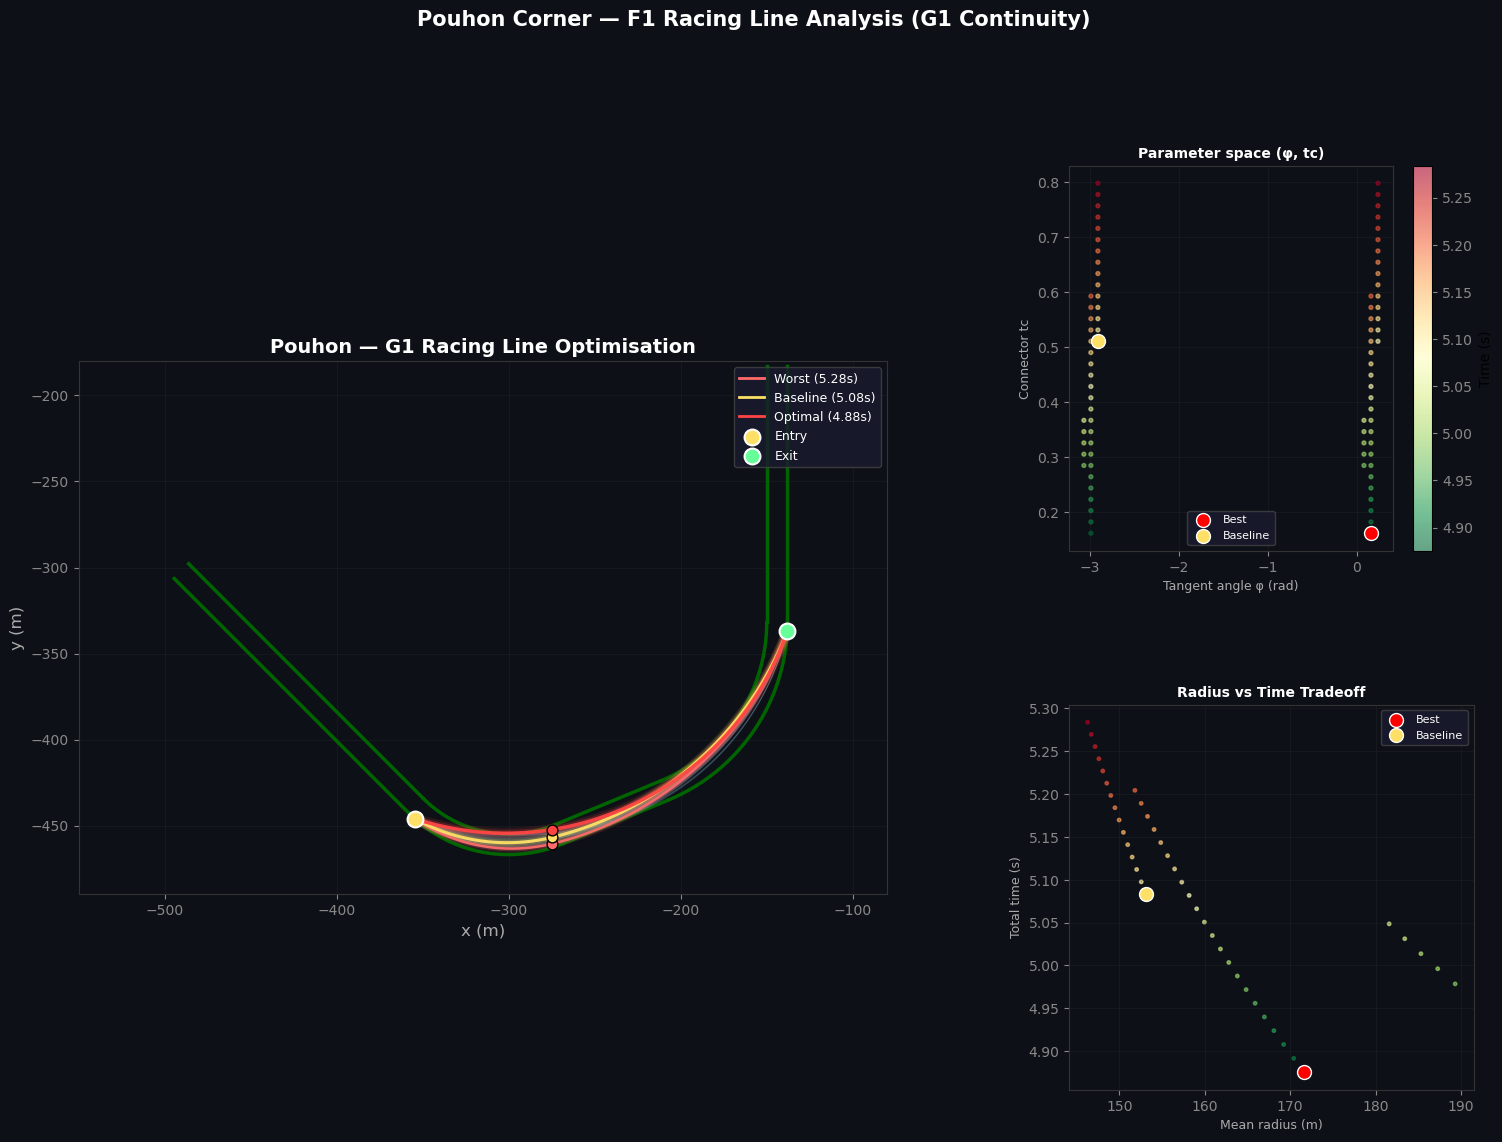

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
import os

os.makedirs('./plots', exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
MU, G   = 1.8, 9.81
slope   = np.tan(np.radians(22.5))
cot22   = 1/np.tan(np.radians(22.5))
c_inner = -336.35
c_outer = -(336.35 + 12/np.cos(np.radians(22.5)))

entry = np.array([-354.66401, -445.97157])
exit_ = np.array([-138.12432, -336.92555])

def connector_point(tc):
    c = c_inner*(1-tc) + c_outer*tc
    return np.array([-275.0, slope*-275.0 + c])

# ── Track boundary ─────────────────────────────────────────────────────────────
def inside_track(x, y):
    in_s1  = ((-x-800.8 <= y <= -x-800.8+12*np.sqrt(2)) and
               (y < x+188.5) and (y > x+300-384.85))
    d1     = np.sqrt((x+300)**2+(y+384.85)**2)
    in_a1  = ((70 - 0.5 <= d1 <= 82 + 0.5) and
               (y < x+300-384.85) and (y+384.85 < -cot22*(x+300)))
    y_in   = slope*x-336.35
    y_out  = slope*x-336.35-12/np.cos(np.radians(22.5))
    in_mid = ((y_out <= y <= y_in) and
               (y+331.65 < -cot22*(x+250)) and (y+384.85 > -cot22*(x+300)))
    d2     = np.sqrt((x+250)**2+(y+331.65)**2)
    in_a2  = ((100 - 0.5 <= d2 <= 112 + 0.5) and
               (y < -331.65) and (y+331.65 > -cot22*(x+250)))
    in_ex  = ((-150 <= x <= -138) and (-331.65 >= y >= -182.62))
    return in_s1 or in_a1 or in_mid or in_a2 or in_ex

def arc_in_track(xs, ys, step=4):
    for x, y in zip(xs[::step], ys[::step]):
        if not inside_track(x, y):
            return False
    return True

# ── G1 circle ──────────────────────────────────────────────────────────────────
def circle_g1(P, J, T):
    N = np.array([-T[1], T[0]])
    d = J - P
    denom = 2*np.dot(d, N)
    if abs(denom) < 1e-8: return None
    r = -np.dot(d,d)/denom
    return J + r*N, r

def arc_stats(P, J, C, r):
    r = abs(r)
    if r < 1e-3: return None
    t1  = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2  = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt  = (t2-t1+np.pi)%(2*np.pi)-np.pi
    arc = r*abs(dt)
    return arc/np.sqrt(MU*G*r), arc, r, abs(np.degrees(dt))

def arc_pts(P, J, C, r, n=400):
    r  = abs(r)
    t1 = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2 = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt = (t2-t1+np.pi)%(2*np.pi)-np.pi
    a  = np.linspace(t1, t1+dt, n)
    return C[0]+r*np.cos(a), C[1]+r*np.sin(a)

# ── Bézier helpers ─────────────────────────────────────────────────────────────
def arc_to_cubic_bezier(C, r, t_start, t_end):
    dt    = t_end - t_start
    alpha = (4/3) * np.tan(dt / 4)
    P0 = C + r * np.array([np.cos(t_start), np.sin(t_start)])
    P3 = C + r * np.array([np.cos(t_end),   np.sin(t_end)])
    T0 = np.array([-np.sin(t_start),  np.cos(t_start)])
    T3 = np.array([-np.sin(t_end),    np.cos(t_end)])
    P1 = P0 + alpha * r * T0
    P2 = P3 - alpha * r * T3
    return P0, P1, P2, P3

def bezier_curve(P0, P1, P2, P3, n=400):
    t = np.linspace(0, 1, n)
    pts = (np.outer((1-t)**3, P0) + np.outer(3*(1-t)**2*t, P1) +
           np.outer(3*(1-t)*t**2, P2) + np.outer(t**3, P3))
    return pts[:, 0], pts[:, 1]

def bezier_derivatives(P0, P1, P2, P3, n=400):
    """Returns first and second derivatives of cubic bezier."""
    t  = np.linspace(0, 1, n)
    t  = t[:, None]   # (n,1) for broadcasting with 2D points
    # First derivative
    d1 = (3*(1-t)**2 * (P1-P0) +
          6*(1-t)*t  * (P2-P1) +
          3*t**2     * (P3-P2))
    # Second derivative
    d2 = (6*(1-t) * (P2-2*P1+P0) +
          6*t     * (P3-2*P2+P1))
    return d1, d2

def curvature(d1, d2):
    """Signed curvature κ = (x'y'' - y'x'') / (x'^2 + y'^2)^(3/2)"""
    cross = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]
    speed = (d1[:, 0]**2 + d1[:, 1]**2)**1.5
    speed = np.where(speed < 1e-10, 1e-10, speed)
    return cross / speed

# ── Optimization ───────────────────────────────────────────────────────────────
N_TC, N_PHI = 40, 80
tc_vals  = np.linspace(0.1, 0.9, N_TC)
phi_vals = np.linspace(-np.pi, np.pi, N_PHI, endpoint=False)

results = []
for tc in tc_vals:
    J = connector_point(tc)
    for phi in phi_vals:
        T = np.array([np.cos(phi), np.sin(phi)])

        r1 = circle_g1(entry, J,  T)
        if r1 is None: continue
        C1, rv1 = r1
        s1 = arc_stats(entry, J, C1, rv1)
        if s1 is None: continue
        t1, l1, r1a, deg1 = s1

        r2 = circle_g1(exit_, J, -T)
        if r2 is None: continue
        C2, rv2 = r2
        s2 = arc_stats(J, exit_, C2, rv2)
        if s2 is None: continue
        t2, l2, r2a, deg2 = s2

        if r1a > 400 or r2a > 400: continue
        if r1a < 10  or r2a < 10:  continue
        if deg1 > 120 or deg2 > 120: continue

        p1 = arc_pts(entry, J,     C1, r1a)
        p2 = arc_pts(J,     exit_, C2, r2a)

        if not arc_in_track(p1[0], p1[1]): continue
        if not arc_in_track(p2[0], p2[1]): continue

        results.append(dict(
            tc=tc, phi=phi, J=J.copy(),
            C1=C1, r1=r1a, l1=l1, deg1=deg1, t1=t1,
            C2=C2, r2=r2a, l2=l2, deg2=deg2, t2=t2,
            time=t1+t2,
            v1=np.sqrt(MU*G*r1a)*3.6,
            v2=np.sqrt(MU*G*r2a)*3.6,
        ))

results.sort(key=lambda x: x['time'])
print(f"Valid trajectories: {len(results)}")
if not results:
    exit("No valid trajectories found.")

best     = results[0]
worst    = results[-1]
baseline = min(results, key=lambda r: (r['tc']-0.5)**2)

print(f"Best:     {best['time']:.3f}s  r1={best['r1']:.1f}m  r2={best['r2']:.1f}m")
print(f"Baseline: {baseline['time']:.3f}s")
print(f"Worst:    {worst['time']:.3f}s")

# Print centers and angles
print(f"\n{'':>24} {'WORST':>10} {'BASELINE':>10} {'BEST':>10}")
print("="*60)
for label, key in [
    ('Radius arc 1 (m)',   'r1'), ('Radius arc 2 (m)',   'r2'),
    ('Speed arc 1 (km/h)', 'v1'), ('Speed arc 2 (km/h)', 'v2'),
    ('Arc 1 length (m)',   'l1'), ('Arc 2 length (m)',   'l2'),
    ('Total time (s)',     'time'),
]:
    print(f"{label:>24} {worst[key]:>10.2f} {baseline[key]:>10.2f} {best[key]:>10.2f}")

print(f"\n{'C1.x (m)':>24} {worst['C1'][0]:>10.2f} {baseline['C1'][0]:>10.2f} {best['C1'][0]:>10.2f}")
print(f"{'C1.y (m)':>24} {worst['C1'][1]:>10.2f} {baseline['C1'][1]:>10.2f} {best['C1'][1]:>10.2f}")
print(f"{'C2.x (m)':>24} {worst['C2'][0]:>10.2f} {baseline['C2'][0]:>10.2f} {best['C2'][0]:>10.2f}")
print(f"{'C2.y (m)':>24} {worst['C2'][1]:>10.2f} {baseline['C2'][1]:>10.2f} {best['C2'][1]:>10.2f}")

for label, res in [('WORST', worst), ('BASELINE', baseline), ('BEST', best)]:
    J = res['J']
    angle_J_from_C1     = np.arctan2(J[1]      - res['C1'][1], J[0]      - res['C1'][0])
    angle_J_from_C2     = np.arctan2(J[1]      - res['C2'][1], J[0]      - res['C2'][0])
    angle_entry_from_C1 = np.arctan2(entry[1]  - res['C1'][1], entry[0]  - res['C1'][0])
    angle_exit_from_C2  = np.arctan2(exit_[1]  - res['C2'][1], exit_[0]  - res['C2'][0])
    dt1 = (angle_J_from_C1 - angle_entry_from_C1 + np.pi) % (2*np.pi) - np.pi
    dt2 = (angle_exit_from_C2 - angle_J_from_C2  + np.pi) % (2*np.pi) - np.pi
    print(f"\n  {label}:")
    print(f"    Arc 1 (C1): entry @ {angle_entry_from_C1:.4f} rad  →  junction @ {angle_J_from_C1:.4f} rad  (sweep {dt1:.4f} rad)")
    print(f"    Arc 2 (C2): junction @ {angle_J_from_C2:.4f} rad  →  exit    @ {angle_exit_from_C2:.4f} rad  (sweep {dt2:.4f} rad)")

    P0_1, P1_1, P2_1, P3_1 = arc_to_cubic_bezier(res['C1'], res['r1'], angle_entry_from_C1, angle_entry_from_C1 + dt1)
    P0_2, P1_2, P2_2, P3_2 = arc_to_cubic_bezier(res['C2'], res['r2'], angle_J_from_C2,    angle_J_from_C2    + dt2)
    print(f"  {label} — Cubic Bézier control points")
    print(f"    Arc 1: P0={P0_1}  P1={P1_1}  P2={P2_1}  P3={P3_1}")
    print(f"    Arc 2: P0={P0_2}  P1={P1_2}  P2={P2_2}  P3={P3_2}")
    print(f"    alpha1={abs((4/3)*np.tan(dt1/4)):.6f}  alpha2={abs((4/3)*np.tan(dt2/4)):.6f}")

# ── Track drawing ──────────────────────────────────────────────────────────────
def draw_track(ax, lw=2.5):
    theta = np.linspace(0, 2*np.pi, 2000)
    col   = 'darkgreen'
    x1 = np.linspace(-600, 200, 2000)
    y = -x1-800.8;               m=(y<x1+188.5)&(y>x1+300-384.85);  ax.plot(x1[m],y[m],col,lw=lw)
    y = -x1-800.8+12*np.sqrt(2); m=(y<x1+188.5)&(y>x1-84.85);       ax.plot(x1[m],y[m],col,lw=lw)
    xc=-300+70*np.cos(theta); yc=-384.85+70*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));                ax.plot(xc[m],yc[m],col,lw=lw)
    xc=-300+82*np.cos(theta); yc=-384.85+82*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));                ax.plot(xc[m],yc[m],col,lw=lw)
    xt = np.linspace(-600, 200, 2000)
    yt=slope*xt-336.35;           m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300)); ax.plot(xt[m],yt[m],col,lw=lw)
    yt=slope*xt-336.35-12/np.cos(np.radians(22.5))
    m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300));       ax.plot(xt[m],yt[m],col,lw=lw)
    xc=-250+100*np.cos(theta); yc=-331.65+100*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                      ax.plot(xc[m],yc[m],col,lw=lw)
    xc=-250+112*np.cos(theta); yc=-331.65+112*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                      ax.plot(xc[m],yc[m],col,lw=lw)
    yv=np.linspace(-500,-150,1000); mv=(yv>-331.65)&(yv<-182.62)
    ax.plot(np.full_like(yv[mv],-150),yv[mv],col,lw=lw)
    ax.plot(np.full_like(yv[mv],-138),yv[mv],col,lw=lw)

# ── Helper: get bezier data for a result ──────────────────────────────────────
def get_bezier_data(res):
    J = res['J']
    t_entry = np.arctan2(entry[1] - res['C1'][1], entry[0] - res['C1'][0])
    t_J1    = np.arctan2(J[1]     - res['C1'][1], J[0]     - res['C1'][0])
    t_J2    = np.arctan2(J[1]     - res['C2'][1], J[0]     - res['C2'][0])
    t_exit  = np.arctan2(exit_[1] - res['C2'][1], exit_[0] - res['C2'][0])
    dt1 = (t_J1   - t_entry + np.pi) % (2*np.pi) - np.pi
    dt2 = (t_exit - t_J2    + np.pi) % (2*np.pi) - np.pi
    P0_1, P1_1, P2_1, P3_1 = arc_to_cubic_bezier(res['C1'], res['r1'], t_entry, t_entry + dt1)
    P0_2, P1_2, P2_2, P3_2 = arc_to_cubic_bezier(res['C2'], res['r2'], t_J2,    t_J2    + dt2)
    x1, y1 = bezier_curve(P0_1, P1_1, P2_1, P3_1)
    x2, y2 = bezier_curve(P0_2, P1_2, P2_2, P3_2)
    d1_1, d2_1 = bezier_derivatives(P0_1, P1_1, P2_1, P3_1)
    d1_2, d2_2 = bezier_derivatives(P0_2, P1_2, P2_2, P3_2)
    k1 = curvature(d1_1, d2_1)
    k2 = curvature(d1_2, d2_2)
    return dict(
        P1=(P0_1, P1_1, P2_1, P3_1), P2=(P0_2, P1_2, P2_2, P3_2),
        x1=x1, y1=y1, x2=x2, y2=y2,
        k1=k1, k2=k2, dt1=dt1, dt2=dt2,
    )

# ── Styled bezier draw ─────────────────────────────────────────────────────────
def draw_bezier_styled(ax, x1, y1, x2, y2, col1, col2, lw=2.5):
    for x, y, col in [(x1, y1, col1), (x2, y2, col2)]:
        ax.plot(x, y, color=col, lw=lw*3.2, alpha=0.12, solid_capstyle='round', zorder=7)
        ax.plot(x, y, color=col, lw=lw*2.0, alpha=0.22, solid_capstyle='round', zorder=7)
        ax.plot(x, y, color=col, lw=lw,     alpha=0.95, solid_capstyle='round', zorder=8)

def draw_control_cage(ax, pts, col):
    px = [p[0] for p in pts]
    py = [p[1] for p in pts]
    ax.plot(px, py, color='white', lw=0.8, ls='-', alpha=0.22, zorder=7)
    for i, p in enumerate(pts):
        is_anchor = i in {0, 3}
        if is_anchor:
            ax.scatter(*p, s=110, facecolors='white',   edgecolors='white', lw=2,   zorder=10)
            ax.scatter(*p, s=50,  facecolors='#0d1117', edgecolors='none',  zorder=11)
        else:
            ax.scatter(*p, s=28, facecolors='#aaaaaa', edgecolors='none', zorder=10)

# ── FIGURE 1: Main optimisation overview ──────────────────────────────────────
fig1 = plt.figure(figsize=(18, 12), facecolor='#0d1117')
gs   = GridSpec(2, 2, figure=fig1, width_ratios=[2, 1], hspace=0.4, wspace=0.3)
ax_track   = fig1.add_subplot(gs[:, 0])
ax_scatter = fig1.add_subplot(gs[0, 1])
ax_tradeoff= fig1.add_subplot(gs[1, 1])

for ax in [ax_track, ax_scatter, ax_tradeoff]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#888888')
    ax.grid(True, alpha=0.15, color='#444444')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')

draw_track(ax_track)

step = max(1, len(results)//500)
for res in results[::step]:
    p1 = arc_pts(entry,    res['J'], res['C1'], res['r1'])
    p2 = arc_pts(res['J'], exit_,   res['C2'], res['r2'])
    ax_track.plot(p1[0], p1[1], color='#7eb8d4', alpha=0.10, lw=0.5)
    ax_track.plot(p2[0], p2[1], color='#7eb8d4', alpha=0.10, lw=0.5)

for res, col, lw, lab, zo in [
    (worst,    '#ff6b6b', 1.8, 'Worst',    8),
    (baseline, '#ffe066', 2.2, 'Baseline', 9),
    (best,     '#ff4444', 2.5, 'Optimal', 10),
]:
    bd = get_bezier_data(res)
    draw_bezier_styled(ax_track, bd['x1'], bd['y1'], bd['x2'], bd['y2'], col, col, lw)
    ax_track.scatter(*res['J'], color=col, s=60, zorder=zo+1, edgecolors='black', lw=1)
    ax_track.plot([], [], color=col, lw=2, label=f"{lab} ({res['time']:.2f}s)")

ax_track.scatter(*entry, color='#ffe066', s=130, zorder=15, edgecolors='white', lw=1.5, label='Entry')
ax_track.scatter(*exit_, color='#66ff99', s=130, zorder=15, edgecolors='white', lw=1.5, label='Exit')
ax_track.set_aspect('equal'); ax_track.set_xlim(-550, -80); ax_track.set_ylim(-490, -180)
ax_track.set_xlabel('x (m)', color='#aaaaaa', fontsize=12)
ax_track.set_ylabel('y (m)', color='#aaaaaa', fontsize=12)
ax_track.set_title('Pouhon — G1 Racing Line Optimisation', color='white', fontsize=14, fontweight='bold')
ax_track.legend(loc='upper right', fontsize=9, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

times = np.array([r['time'] for r in results])
phis  = np.array([r['phi']  for r in results])
tcs   = np.array([r['tc']   for r in results])
sc = ax_scatter.scatter(phis, tcs, c=times, cmap='RdYlGn_r', s=8, alpha=0.6)
cb = plt.colorbar(sc, ax=ax_scatter, label='Time (s)')
cb.ax.yaxis.set_tick_params(color='#888888'); cb.ax.tick_params(colors='#888888')
ax_scatter.scatter(best['phi'],     best['tc'],     color='red',    s=100, zorder=5, edgecolors='white', label='Best')
ax_scatter.scatter(baseline['phi'], baseline['tc'], color='#ffe066',s=100, zorder=5, edgecolors='white', label='Baseline')
ax_scatter.set_xlabel('Tangent angle φ (rad)', color='#aaaaaa', fontsize=9)
ax_scatter.set_ylabel('Connector tc',           color='#aaaaaa', fontsize=9)
ax_scatter.set_title('Parameter space (φ, tc)', color='white', fontsize=10, fontweight='bold')
ax_scatter.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

r_avg = np.array([(r['r1']+r['r2'])/2 for r in results])
ax_tradeoff.scatter(r_avg, times, c=times, cmap='RdYlGn_r', s=6, alpha=0.4)
ax_tradeoff.scatter((best['r1']+best['r2'])/2,     best['time'],     color='red',    s=100, zorder=5, edgecolors='white', label='Best')
ax_tradeoff.scatter((baseline['r1']+baseline['r2'])/2, baseline['time'], color='#ffe066',s=100, zorder=5, edgecolors='white', label='Baseline')
ax_tradeoff.set_xlabel('Mean radius (m)', color='#aaaaaa', fontsize=9)
ax_tradeoff.set_ylabel('Total time (s)', color='#aaaaaa', fontsize=9)
ax_tradeoff.set_title('Radius vs Time Tradeoff', color='white', fontsize=10, fontweight='bold')
ax_tradeoff.legend(fontsize=8, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

fig1.patch.set_facecolor('#0d1117')
plt.suptitle('Pouhon Corner — F1 Racing Line Analysis (G1 Continuity)',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('./plots/pouhon_overview.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
print("Saved pouhon_overview.png")

# ── FIGURE 2: Bézier diagram per trajectory ────────────────────────────────────
def plot_bezier_diagram(res, label, filename):
    bd  = get_bezier_data(res)
    J   = res['J']
    fig, ax = plt.subplots(figsize=(13, 9), facecolor='#0d1117')
    ax.set_facecolor('#0d1117')
    draw_track(ax)

    # Reference circles (faint)
    theta = np.linspace(0, 2*np.pi, 400)
    for C, r, col in [(res['C1'], res['r1'], '#2a4a6b'), (res['C2'], res['r2'], '#2a6b4a')]:
        ax.plot(C[0]+r*np.cos(theta), C[1]+r*np.sin(theta),
                color=col, lw=0.8, ls='--', alpha=0.35)
        ax.scatter(*C, color=col, s=35, zorder=5, alpha=0.7)
        ax.annotate(f'C ({C[0]:.0f}, {C[1]:.0f})', xy=C,
                    xytext=(C[0]+4, C[1]+4), color=col, fontsize=7, alpha=0.9)

    # Styled bezier curves
    draw_bezier_styled(ax, bd['x1'], bd['y1'], bd['x2'], bd['y2'],
                       '#5ba3d0', '#d07a5b', lw=2.8)

    # Control cages
    draw_control_cage(ax, bd['P1'], '#5ba3d0')
    draw_control_cage(ax, bd['P2'], '#d07a5b')

    # Label control points
    offset = 5
    for pts, col, arc_label in [(bd['P1'], '#5ba3d0', '1'), (bd['P2'], '#d07a5b', '2')]:
        names = [f'P{i}' for i in range(4)]
        for i, (p, name) in enumerate(zip(pts, names)):
            ax.annotate(f'{name}', xy=p,
                        xytext=(p[0]+offset, p[1]+offset),
                        color=col, fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec=col, alpha=0.75))

    # Junction
    ax.scatter(*J, s=130, facecolors='white', edgecolors='#ffee44', lw=2.5, zorder=12)
    ax.scatter(*J, s=55,  facecolors='#0d1117', edgecolors='none', zorder=13)
    ax.annotate(f'J ({J[0]:.1f}, {J[1]:.1f})', xy=J,
                xytext=(J[0]+6, J[1]-12), color='#ffee44', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='#ffee44', alpha=0.8))

    # G1 tangent arrow
    t_J1 = np.arctan2(J[1]-res['C1'][1], J[0]-res['C1'][0])
    tang  = np.array([-np.sin(t_J1 + bd['dt1']), np.cos(t_J1 + bd['dt1'])]) * 20
    ax.annotate('', xy=J+tang, xytext=J-tang,
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))
    ax.text(J[0]+tang[0]+3, J[1]+tang[1], 'G1', color='white', fontsize=8, alpha=0.8)

    # Entry / exit
    ax.scatter(*entry, color='#ffe066', s=130, zorder=12, edgecolors='white', lw=1.5)
    ax.scatter(*exit_, color='#66ff99', s=130, zorder=12, edgecolors='white', lw=1.5)
    ax.annotate('Entry', xy=entry, xytext=(entry[0]-5, entry[1]-14),
                color='#ffe066', fontsize=8, fontweight='bold')
    ax.annotate('Exit',  xy=exit_,  xytext=(exit_[0]+4,  exit_[1]-14),
                color='#66ff99', fontsize=8, fontweight='bold')

    # Stats box
    a1 = abs((4/3)*np.tan(bd['dt1']/4))
    a2 = abs((4/3)*np.tan(bd['dt2']/4))
    stats = (f"Arc 1  r={res['r1']:.1f}m  sweep={np.degrees(abs(bd['dt1'])):.1f}°  α={a1:.4f}\n"
             f"Arc 2  r={res['r2']:.1f}m  sweep={np.degrees(abs(bd['dt2'])):.1f}°  α={a2:.4f}\n"
             f"Total time: {res['time']:.3f} s    v1={res['v1']:.0f} km/h  v2={res['v2']:.0f} km/h")
    ax.text(0.02, 0.03, stats, transform=ax.transAxes,
            color='white', fontsize=8.5, fontfamily='monospace',
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', fc='#1a2a3a', ec='#336699', alpha=0.9))

    # Legend proxies
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], color='#5ba3d0', lw=2.5, label='Arc 1 Bézier'),
        Line2D([0],[0], color='#d07a5b', lw=2.5, label='Arc 2 Bézier'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
              facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')

    ax.set_aspect('equal'); ax.set_xlim(-550, -80); ax.set_ylim(-490, -180)
    ax.tick_params(colors='#888888')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
    ax.set_xlabel('x (m)', color='#aaaaaa', fontsize=11)
    ax.set_ylabel('y (m)', color='#aaaaaa', fontsize=11)
    ax.set_title(f'Pouhon — Cubic Bézier ({label})',
                 color='white', fontsize=13, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.12, color='#444444')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    print(f"Saved {filename}")
    plt.close()

for lab, res in [('WORST', worst), ('BASELINE', baseline), ('BEST', best)]:
    plot_bezier_diagram(res, lab, f'./plots/bezier_{lab.lower()}.png')

# ── FIGURE 3: Curvature comb diagram ──────────────────────────────────────────
def plot_curvature_comb(res, label, filename):
    bd  = get_bezier_data(res)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor='#0d1117')
    fig.suptitle(f'Pouhon — Curvature Comb ({label})',
                 color='white', fontsize=14, fontweight='bold')

    # ── Left: spatial comb on track ───────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor('#0d1117')
    draw_track(ax)

    comb_scale = 600   # visual scale factor for comb teeth length

    for (xs, ys, ks, col) in [
        (bd['x1'], bd['y1'], bd['k1'], '#5ba3d0'),
        (bd['x2'], bd['y2'], bd['k2'], '#d07a5b'),
    ]:
        # Curve
        ax.plot(xs, ys, color=col, lw=3.0, alpha=0.95, solid_capstyle='round', zorder=8)
        ax.plot(xs, ys, color=col, lw=7.0, alpha=0.12, solid_capstyle='round', zorder=7)

        # Compute normals from finite differences
        dx = np.gradient(xs); dy = np.gradient(ys)
        speed = np.sqrt(dx**2 + dy**2)
        speed = np.where(speed < 1e-10, 1e-10, speed)
        nx = -dy / speed   # unit normal
        ny =  dx / speed

        # Draw teeth
        step = 8
        tip_x = xs[::step] + nx[::step] * ks[::step] * comb_scale
        tip_y = ys[::step] + ny[::step] * ks[::step] * comb_scale

        for i, (x0, y0, x1, y1) in enumerate(zip(xs[::step], ys[::step], tip_x, tip_y)):
            ax.plot([x0, x1], [y0, y1], color=col, lw=0.9, alpha=0.55, zorder=9)

        # Comb envelope
        ax.plot(tip_x, tip_y, color=col, lw=1.2, alpha=0.7, zorder=9, ls='-')

    # Junction
    ax.scatter(*res['J'], s=110, facecolors='white', edgecolors='#ffee44', lw=2, zorder=12)
    ax.scatter(*res['J'], s=45,  facecolors='#0d1117', edgecolors='none', zorder=13)
    ax.annotate('J', xy=res['J'], xytext=(res['J'][0]+5, res['J'][1]-12),
                color='#ffee44', fontsize=9, fontweight='bold')
    ax.scatter(*entry, color='#ffe066', s=110, zorder=12, edgecolors='white', lw=1.5)
    ax.scatter(*exit_, color='#66ff99', s=110, zorder=12, edgecolors='white', lw=1.5)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0],[0], color='#5ba3d0', lw=2, label=f'Arc 1 (r={res["r1"]:.1f}m)'),
        Line2D([0],[0], color='#d07a5b', lw=2, label=f'Arc 2 (r={res["r2"]:.1f}m)'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
              facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
    ax.set_aspect('equal'); ax.set_xlim(-550, -80); ax.set_ylim(-490, -180)
    ax.tick_params(colors='#888888')
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
    ax.set_xlabel('x (m)', color='#aaaaaa', fontsize=11)
    ax.set_ylabel('y (m)', color='#aaaaaa', fontsize=11)
    ax.set_title('Spatial Curvature Comb', color='white', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.12, color='#444444')
    ax.text(0.02, 0.03,
            f'Comb teeth ∝ κ (scale ×{comb_scale})\nPointing toward center of curvature',
            transform=ax.transAxes, color='#aaaaaa', fontsize=8, fontfamily='monospace',
            bbox=dict(boxstyle='round', fc='#1a2a3a', ec='#336699', alpha=0.85))

    # ── Right: κ vs arc-length plot ───────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#0d1117')
    ax2.tick_params(colors='#888888')
    for sp in ax2.spines.values(): sp.set_edgecolor('#333333')
    ax2.grid(True, alpha=0.15, color='#444444')

    # Arc-length parameterisation for each bezier
    def arc_length_param(xs, ys):
        dx = np.diff(xs); dy = np.diff(ys)
        ds = np.sqrt(dx**2 + dy**2)
        s  = np.concatenate([[0], np.cumsum(ds)])
        return s

    s1 = arc_length_param(bd['x1'], bd['y1'])
    s2 = arc_length_param(bd['x2'], bd['y2'])
    # offset arc 2 to be continuous
    s2_offset = s2 + s1[-1]

    ax2.plot(s1, bd['k1'], color='#5ba3d0', lw=2.2, label=f'Arc 1  (r={res["r1"]:.1f}m)')
    ax2.plot(s2_offset, bd['k2'], color='#d07a5b', lw=2.2, label=f'Arc 2  (r={res["r2"]:.1f}m)')

    # Fill under curves
    ax2.fill_between(s1,       bd['k1'], alpha=0.15, color='#5ba3d0')
    ax2.fill_between(s2_offset, bd['k2'], alpha=0.15, color='#d07a5b')

    # Mark junction
    ax2.axvline(x=s1[-1], color='#ffee44', lw=1.2, ls='--', alpha=0.7, label='Junction (G1)')

    # Theoretical constant curvature lines
    k_theory_1 = 1/res['r1']
    k_theory_2 = 1/res['r2']
    ax2.axhline(y= k_theory_1, color='#5ba3d0', lw=1, ls=':', alpha=0.5)
    ax2.axhline(y=-k_theory_1, color='#5ba3d0', lw=1, ls=':', alpha=0.5)
    ax2.axhline(y= k_theory_2, color='#d07a5b', lw=1, ls=':', alpha=0.5)
    ax2.axhline(y=-k_theory_2, color='#d07a5b', lw=1, ls=':', alpha=0.5)
    ax2.text(s1[-1]/2,  k_theory_1*1.05, f'κ=1/r₁', color='#5ba3d0', fontsize=7, alpha=0.7, ha='center')
    ax2.text(s1[-1]/2, -k_theory_1*1.05, f'κ=-1/r₁', color='#5ba3d0', fontsize=7, alpha=0.7, ha='center')

    ax2.set_xlabel('Arc length (m)', color='#aaaaaa', fontsize=11)
    ax2.set_ylabel('Curvature κ (m⁻¹)', color='#aaaaaa', fontsize=11)
    ax2.set_title('Curvature vs Arc Length', color='white', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, facecolor='#1a1a2e', edgecolor='#444', labelcolor='white')
    ax2.axhline(y=0, color='#555555', lw=0.8)

    # Annotate G1 discontinuity in curvature
    k_end_arc1   = bd['k1'][-1]
    k_start_arc2 = bd['k2'][0]
    ax2.annotate(f'Δκ = {abs(k_end_arc1 - k_start_arc2):.5f}',
                 xy=(s1[-1], (k_end_arc1+k_start_arc2)/2),
                 xytext=(s1[-1]+8, (k_end_arc1+k_start_arc2)/2 + 0.001),
                 color='#ffee44', fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='#ffee44', lw=1),
                 bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='#ffee44', alpha=0.8))

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    print(f"Saved {filename}")
    plt.close()

for lab, res in [('WORST', worst), ('BASELINE', baseline), ('BEST', best)]:
    plot_curvature_comb(res, lab, f'./plots/curvature_comb_{lab.lower()}.png')

print("\nAll done.")

Guardado.


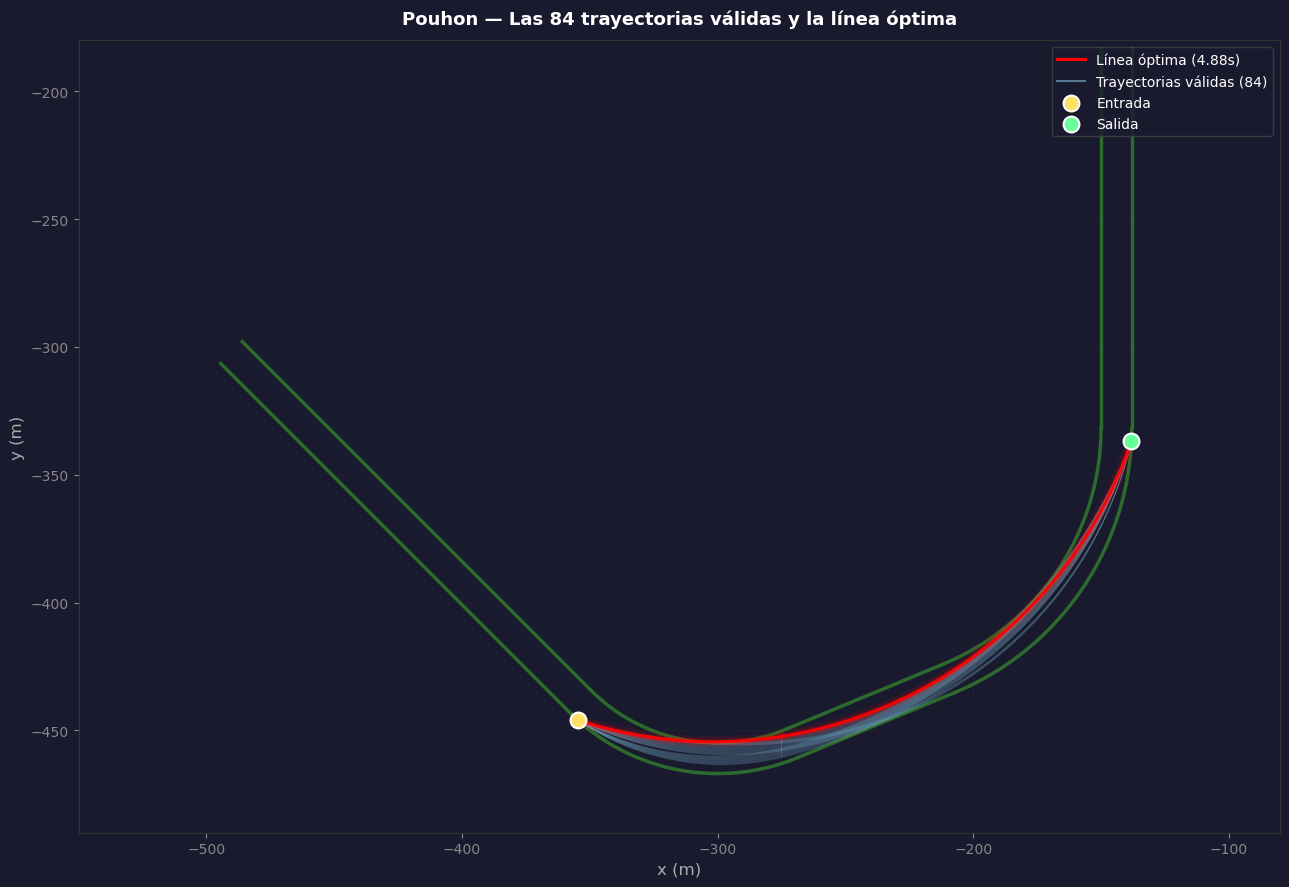

In [8]:
import numpy as np
import matplotlib.pyplot as plt

MU, G   = 1.8, 9.81
slope   = np.tan(np.radians(22.5))
cot22   = 1/np.tan(np.radians(22.5))
c_inner = -336.35
c_outer = -(336.35 + 12/np.cos(np.radians(22.5)))

entry = np.array([-354.66401, -445.97157])
exit_ = np.array([-138.12432, -336.92555])

def connector_point(tc):
    c = c_inner*(1-tc) + c_outer*tc
    return np.array([-275.0, slope*-275.0 + c])

def inside_track(x, y):
    in_s1  = ((-x-800.8 <= y <= -x-800.8+12*np.sqrt(2)) and (y < x+188.5) and (y > x+300-384.85))
    d1     = np.sqrt((x+300)**2+(y+384.85)**2)
    in_a1  = ((70-0.5 <= d1 <= 82+0.5) and (y < x+300-384.85) and (y+384.85 < -cot22*(x+300)))
    y_in   = slope*x-336.35
    y_out  = slope*x-336.35-12/np.cos(np.radians(22.5))
    in_mid = ((y_out <= y <= y_in) and (y+331.65 < -cot22*(x+250)) and (y+384.85 > -cot22*(x+300)))
    d2     = np.sqrt((x+250)**2+(y+331.65)**2)
    in_a2  = ((100-0.5 <= d2 <= 112+0.5) and (y < -331.65) and (y+331.65 > -cot22*(x+250)))
    in_ex  = ((-150 <= x <= -138) and (-331.65 >= y >= -182.62))
    return in_s1 or in_a1 or in_mid or in_a2 or in_ex

def arc_in_track(xs, ys, step=4):
    for x, y in zip(xs[::step], ys[::step]):
        if not inside_track(x, y): return False
    return True

def circle_g1(P, J, T):
    N = np.array([-T[1], T[0]])
    d = J - P
    denom = 2*np.dot(d, N)
    if abs(denom) < 1e-8: return None
    r = -np.dot(d,d)/denom
    return J + r*N, r

def arc_stats(P, J, C, r):
    r = abs(r)
    if r < 1e-3: return None
    t1  = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2  = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt  = (t2-t1+np.pi)%(2*np.pi)-np.pi
    arc = r*abs(dt)
    return arc/np.sqrt(MU*G*r), arc, r, abs(np.degrees(dt))

def arc_pts(P, J, C, r, n=400):
    r  = abs(r)
    t1 = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2 = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt = (t2-t1+np.pi)%(2*np.pi)-np.pi
    a  = np.linspace(t1, t1+dt, n)
    return C[0]+r*np.cos(a), C[1]+r*np.sin(a)

results = []
for tc in np.linspace(0.1, 0.9, 40):
    J = connector_point(tc)
    for phi in np.linspace(-np.pi, np.pi, 80, endpoint=False):
        T = np.array([np.cos(phi), np.sin(phi)])
        r1 = circle_g1(entry, J,  T)
        if r1 is None: continue
        C1, rv1 = r1
        s1 = arc_stats(entry, J, C1, rv1)
        if s1 is None: continue
        t1, l1, r1a, deg1 = s1
        r2 = circle_g1(exit_, J, -T)
        if r2 is None: continue
        C2, rv2 = r2
        s2 = arc_stats(J, exit_, C2, rv2)
        if s2 is None: continue
        t2, l2, r2a, deg2 = s2
        if r1a > 400 or r2a > 400: continue
        if r1a < 10  or r2a < 10:  continue
        if deg1 > 120 or deg2 > 120: continue
        p1 = arc_pts(entry, J,     C1, r1a)
        p2 = arc_pts(J,     exit_, C2, r2a)
        if not arc_in_track(p1[0], p1[1]): continue
        if not arc_in_track(p2[0], p2[1]): continue
        results.append(dict(
            tc=tc, phi=phi, J=J.copy(),
            C1=C1, r1=r1a, l1=l1, deg1=deg1, t1=t1,
            C2=C2, r2=r2a, l2=l2, deg2=deg2, t2=t2,
            time=t1+t2,
        ))

results.sort(key=lambda x: x['time'])
best = results[0]

# ── Dark-style track draw ─────────────────────────────────────────────────────
def draw_track(ax):
    theta = np.linspace(0, 2*np.pi, 2000)
    col = '#2d6a2d'
    x1 = np.linspace(-600, 200, 2000)
    y=-x1-800.8;               m=(y<x1+188.5)&(y>x1+300-384.85);  ax.plot(x1[m],y[m],col,lw=2.5)
    y=-x1-800.8+12*np.sqrt(2); m=(y<x1+188.5)&(y>x1-84.85);       ax.plot(x1[m],y[m],col,lw=2.5)
    xc=-300+70*np.cos(theta);  yc=-384.85+70*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));              ax.plot(xc[m],yc[m],col,lw=2.5)
    xc=-300+82*np.cos(theta);  yc=-384.85+82*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));              ax.plot(xc[m],yc[m],col,lw=2.5)
    xt=np.linspace(-600,200,2000)
    yt=slope*xt-336.35;        m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300)); ax.plot(xt[m],yt[m],col,lw=2.5)
    yt=slope*xt-336.35-12/np.cos(np.radians(22.5))
    m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300));     ax.plot(xt[m],yt[m],col,lw=2.5)
    xc=-250+100*np.cos(theta); yc=-331.65+100*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                    ax.plot(xc[m],yc[m],col,lw=2.5)
    xc=-250+112*np.cos(theta); yc=-331.65+112*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                    ax.plot(xc[m],yc[m],col,lw=2.5)
    yv=np.linspace(-500,-150,1000); mv=(yv>-331.65)&(yv<-182.62)
    ax.plot(np.full_like(yv[mv],-150),yv[mv],col,lw=2.5)
    ax.plot(np.full_like(yv[mv],-138),yv[mv],col,lw=2.5)

fig, ax = plt.subplots(figsize=(13, 10), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

draw_track(ax)

# All valid trajectories — filled shading between the two arcs
step = max(1, len(results)//500)
for res in results[::step]:
    p1 = arc_pts(entry,    res['J'], res['C1'], res['r1'])
    p2 = arc_pts(res['J'], exit_,   res['C2'], res['r2'])
    ax.plot(p1[0], p1[1], color='#7eb8d4', alpha=0.12, lw=0.6, zorder=5)
    ax.plot(p2[0], p2[1], color='#7eb8d4', alpha=0.12, lw=0.6, zorder=5)

# Optimal line — styled glow
p1b = arc_pts(entry,     best['J'], best['C1'], best['r1'])
p2b = arc_pts(best['J'], exit_,    best['C2'], best['r2'])
for xs, ys in [(p1b, p1b[1]*0+p1b[1]), (p2b, p2b[1]*0+p2b[1])]:
    pass

for xs, ys in [(p1b, None), (p2b, None)]:
    ax.plot(p1b[0] if xs is p1b else p2b[0],
            p1b[1] if xs is p1b else p2b[1],
            color='red', lw=8.0, alpha=0.10, solid_capstyle='round', zorder=8)
    ax.plot(p1b[0] if xs is p1b else p2b[0],
            p1b[1] if xs is p1b else p2b[1],
            color='red', lw=4.5, alpha=0.20, solid_capstyle='round', zorder=8)
    ax.plot(p1b[0] if xs is p1b else p2b[0],
            p1b[1] if xs is p1b else p2b[1],
            color='red', lw=2.2, alpha=0.95, solid_capstyle='round', zorder=9)

ax.plot([], [], color='red',     lw=2.2, label=f'Línea óptima ({best["time"]:.2f}s)')
ax.plot([], [], color='#7eb8d4', lw=1.5, alpha=0.6, label=f'Trayectorias válidas ({len(results)})')

ax.scatter(*entry, color='#ffe066', s=130, zorder=15, edgecolors='white', lw=1.5, label='Entrada')
ax.scatter(*exit_, color='#66ff99', s=130, zorder=15, edgecolors='white', lw=1.5, label='Salida')

ax.set_aspect('equal')
ax.set_xlim(-550, -80)
ax.set_ylim(-490, -180)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')
ax.grid(True, alpha=0.12, color='#444444')
ax.set_xlabel('x (m)', color='#aaaaaa', fontsize=12)
ax.set_ylabel('y (m)', color='#aaaaaa', fontsize=12)
ax.set_title(f'Pouhon — Las {len(results)} trayectorias válidas y la línea óptima',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper right', fontsize=10,
          facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/figura4_es.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
print("Guardado.")

Guardado.


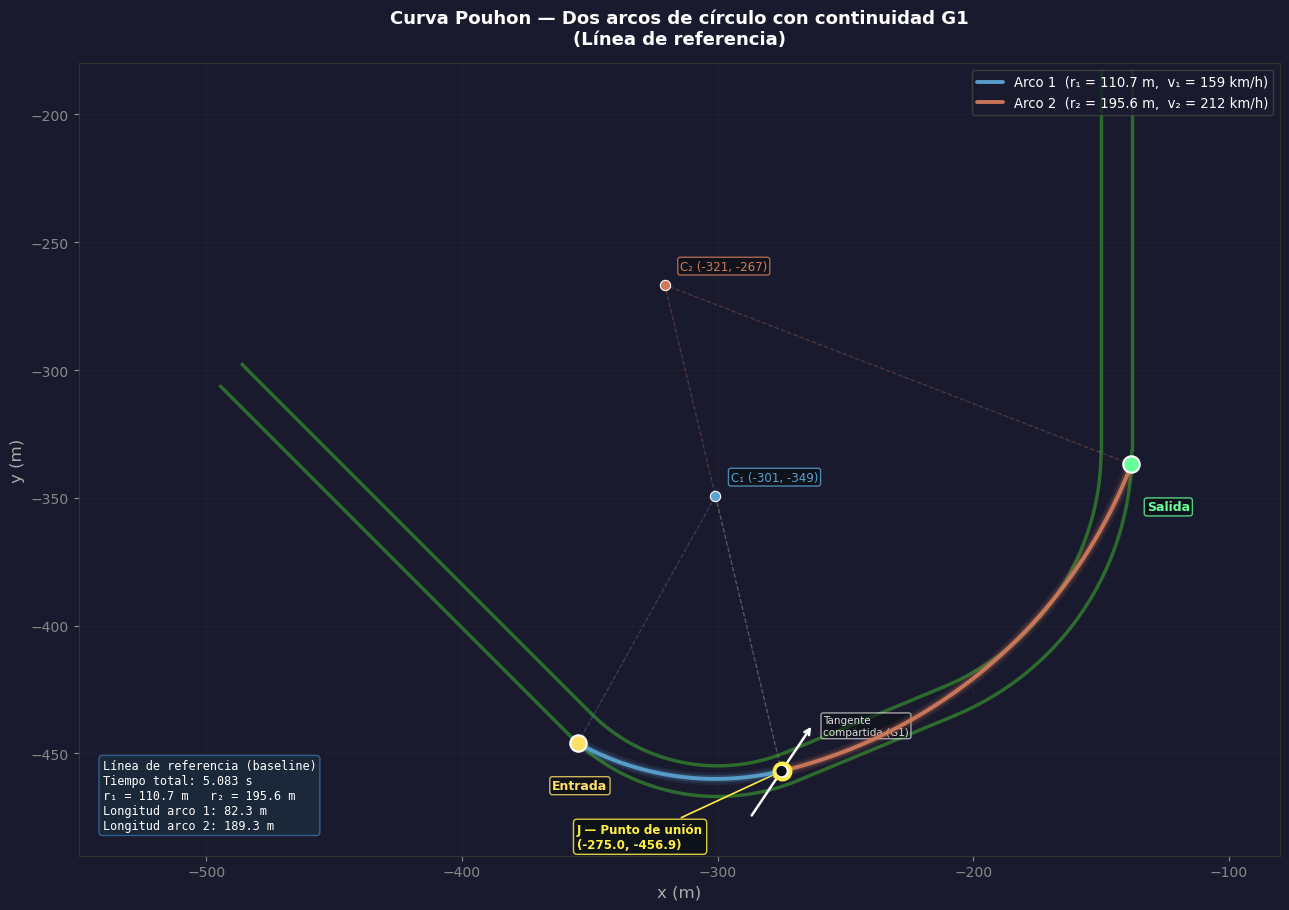

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


MU, G   = 1.8, 9.81
slope   = np.tan(np.radians(22.5))
cot22   = 1/np.tan(np.radians(22.5))
c_inner = -336.35
c_outer = -(336.35 + 12/np.cos(np.radians(22.5)))

entry = np.array([-354.66401, -445.97157])
exit_ = np.array([-138.12432, -336.92555])

def connector_point(tc):
    c = c_inner*(1-tc) + c_outer*tc
    return np.array([-275.0, slope*-275.0 + c])

def inside_track(x, y):
    in_s1  = ((-x-800.8 <= y <= -x-800.8+12*np.sqrt(2)) and
               (y < x+188.5) and (y > x+300-384.85))
    d1     = np.sqrt((x+300)**2+(y+384.85)**2)
    in_a1  = ((70 - 0.5 <= d1 <= 82 + 0.5) and
               (y < x+300-384.85) and (y+384.85 < -cot22*(x+300)))
    y_in   = slope*x-336.35
    y_out  = slope*x-336.35-12/np.cos(np.radians(22.5))
    in_mid = ((y_out <= y <= y_in) and
               (y+331.65 < -cot22*(x+250)) and (y+384.85 > -cot22*(x+300)))
    d2     = np.sqrt((x+250)**2+(y+331.65)**2)
    in_a2  = ((100 - 0.5 <= d2 <= 112 + 0.5) and
               (y < -331.65) and (y+331.65 > -cot22*(x+250)))
    in_ex  = ((-150 <= x <= -138) and (-331.65 >= y >= -182.62))
    return in_s1 or in_a1 or in_mid or in_a2 or in_ex

def arc_in_track(xs, ys, step=4):
    for x, y in zip(xs[::step], ys[::step]):
        if not inside_track(x, y):
            return False
    return True

def circle_g1(P, J, T):
    N = np.array([-T[1], T[0]])
    d = J - P
    denom = 2*np.dot(d, N)
    if abs(denom) < 1e-8: return None
    r = -np.dot(d,d)/denom
    return J + r*N, r

def arc_stats(P, J, C, r):
    r = abs(r)
    if r < 1e-3: return None
    t1  = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2  = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt  = (t2-t1+np.pi)%(2*np.pi)-np.pi
    arc = r*abs(dt)
    return arc/np.sqrt(MU*G*r), arc, r, abs(np.degrees(dt))

def arc_pts(P, J, C, r, n=600):
    r  = abs(r)
    t1 = np.arctan2(P[1]-C[1], P[0]-C[0])
    t2 = np.arctan2(J[1]-C[1], J[0]-C[0])
    dt = (t2-t1+np.pi)%(2*np.pi)-np.pi
    a  = np.linspace(t1, t1+dt, n)
    return C[0]+r*np.cos(a), C[1]+r*np.sin(a)

# Optimization
N_TC, N_PHI = 40, 80
tc_vals  = np.linspace(0.1, 0.9, N_TC)
phi_vals = np.linspace(-np.pi, np.pi, N_PHI, endpoint=False)

results = []
for tc in tc_vals:
    J = connector_point(tc)
    for phi in phi_vals:
        T = np.array([np.cos(phi), np.sin(phi)])
        r1 = circle_g1(entry, J,  T)
        if r1 is None: continue
        C1, rv1 = r1
        s1 = arc_stats(entry, J, C1, rv1)
        if s1 is None: continue
        t1, l1, r1a, deg1 = s1
        r2 = circle_g1(exit_, J, -T)
        if r2 is None: continue
        C2, rv2 = r2
        s2 = arc_stats(J, exit_, C2, rv2)
        if s2 is None: continue
        t2, l2, r2a, deg2 = s2
        if r1a > 400 or r2a > 400: continue
        if r1a < 10  or r2a < 10:  continue
        if deg1 > 120 or deg2 > 120: continue
        p1 = arc_pts(entry, J,     C1, r1a)
        p2 = arc_pts(J,     exit_, C2, r2a)
        if not arc_in_track(p1[0], p1[1]): continue
        if not arc_in_track(p2[0], p2[1]): continue
        results.append(dict(
            tc=tc, phi=phi, J=J.copy(),
            C1=C1, r1=r1a, l1=l1, deg1=deg1, t1=t1,
            C2=C2, r2=r2a, l2=l2, deg2=deg2, t2=t2,
            time=t1+t2,
            v1=np.sqrt(MU*G*r1a)*3.6,
            v2=np.sqrt(MU*G*r2a)*3.6,
        ))

results.sort(key=lambda x: x['time'])
baseline = min(results, key=lambda r: (r['tc']-0.5)**2)

def draw_track(ax, lw=2.5):
    theta = np.linspace(0, 2*np.pi, 2000)
    col = '#2d6a2d'
    x1 = np.linspace(-600, 200, 2000)
    y=-x1-800.8;               m=(y<x1+188.5)&(y>x1+300-384.85);  ax.plot(x1[m],y[m],col,lw=lw)
    y=-x1-800.8+12*np.sqrt(2); m=(y<x1+188.5)&(y>x1-84.85);       ax.plot(x1[m],y[m],col,lw=lw)
    xc=-300+70*np.cos(theta);  yc=-384.85+70*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));              ax.plot(xc[m],yc[m],col,lw=lw)
    xc=-300+82*np.cos(theta);  yc=-384.85+82*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot22*(xc+300));              ax.plot(xc[m],yc[m],col,lw=lw)
    xt=np.linspace(-600,200,2000)
    yt=slope*xt-336.35;        m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300)); ax.plot(xt[m],yt[m],col,lw=lw)
    yt=slope*xt-336.35-12/np.cos(np.radians(22.5))
    m=(yt+331.65<-cot22*(xt+250))&(yt+384.85>-cot22*(xt+300));     ax.plot(xt[m],yt[m],col,lw=lw)
    xc=-250+100*np.cos(theta); yc=-331.65+100*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                    ax.plot(xc[m],yc[m],col,lw=lw)
    xc=-250+112*np.cos(theta); yc=-331.65+112*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot22*(xc+250));                    ax.plot(xc[m],yc[m],col,lw=lw)
    yv=np.linspace(-500,-150,1000); mv=(yv>-331.65)&(yv<-182.62)
    ax.plot(np.full_like(yv[mv],-150),yv[mv],col,lw=lw)
    ax.plot(np.full_like(yv[mv],-138),yv[mv],col,lw=lw)

res = baseline
J   = res['J']

p1x, p1y = arc_pts(entry, J,     res['C1'], res['r1'])
p2x, p2y = arc_pts(J,     exit_, res['C2'], res['r2'])

fig, ax = plt.subplots(figsize=(13, 10), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

draw_track(ax)

# Arc glow + line
for xs, ys, col, lbl in [
    (p1x, p1y, '#5ba3d0', f'Arco 1  (r₁ = {res["r1"]:.1f} m,  v₁ = {res["v1"]:.0f} km/h)'),
    (p2x, p2y, '#d07a5b', f'Arco 2  (r₂ = {res["r2"]:.1f} m,  v₂ = {res["v2"]:.0f} km/h)'),
]:
    ax.plot(xs, ys, color=col, lw=9.0, alpha=0.10, solid_capstyle='round', zorder=7)
    ax.plot(xs, ys, color=col, lw=5.5, alpha=0.20, solid_capstyle='round', zorder=7)
    ax.plot(xs, ys, color=col, lw=2.8, alpha=0.95, solid_capstyle='round', zorder=8, label=lbl)

# Radius lines to centers
for P, C, col in [(entry, res['C1'], '#5ba3d0'), (J, res['C1'], '#5ba3d0'),
                  (J,     res['C2'], '#d07a5b'), (exit_, res['C2'], '#d07a5b')]:
    ax.plot([P[0], C[0]], [P[1], C[1]], color=col, lw=0.9, ls='--', alpha=0.30, zorder=6)

# Centers
ax.scatter(*res['C1'], color='#5ba3d0', s=55, zorder=9, edgecolors='white', lw=0.8)
ax.scatter(*res['C2'], color='#d07a5b', s=55, zorder=9, edgecolors='white', lw=0.8)
ax.annotate(f'C₁ ({res["C1"][0]:.0f}, {res["C1"][1]:.0f})',
            xy=res['C1'], xytext=(res['C1'][0]+6, res['C1'][1]+6),
            color='#5ba3d0', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='#5ba3d0', alpha=0.8))
ax.annotate(f'C₂ ({res["C2"][0]:.0f}, {res["C2"][1]:.0f})',
            xy=res['C2'], xytext=(res['C2'][0]+6, res['C2'][1]+6),
            color='#d07a5b', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='#d07a5b', alpha=0.8))

# Junction J
ax.scatter(*J, s=140, facecolors='white', edgecolors='#ffee44', lw=2.5, zorder=12)
ax.scatter(*J, s=55,  facecolors='#0d1117', edgecolors='none', zorder=13)
ax.annotate(f'J — Punto de unión\n({J[0]:.1f}, {J[1]:.1f})',
            xy=J, xytext=(J[0]-80, J[1]-30),
            color='#ffee44', fontsize=8.5, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#ffee44', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#0d1117', ec='#ffee44', alpha=0.85))

# Entry / exit
ax.scatter(*entry, color='#ffe066', s=140, zorder=12, edgecolors='white', lw=1.5)
ax.scatter(*exit_, color='#66ff99', s=140, zorder=12, edgecolors='white', lw=1.5)
ax.annotate('Entrada', xy=entry, xytext=(entry[0]-10, entry[1]-18),
            color='#ffe066', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='#ffe066', alpha=0.8))
ax.annotate('Salida', xy=exit_, xytext=(exit_[0]+6, exit_[1]-18),
            color='#66ff99', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='#66ff99', alpha=0.8))

# G1 tangent arrow at J
t_J1 = np.arctan2(J[1]-res['C1'][1], J[0]-res['C1'][0])
dt1  = (np.arctan2(J[1]-res['C1'][1], J[0]-res['C1'][0]) -
        np.arctan2(entry[1]-res['C1'][1], entry[0]-res['C1'][0]) + np.pi) % (2*np.pi) - np.pi
tang = np.array([-np.sin(t_J1 + dt1), np.cos(t_J1 + dt1)]) * 22
ax.annotate('', xy=J+tang, xytext=J-tang,
            arrowprops=dict(arrowstyle='->', color='white', lw=1.8))
ax.text(J[0]+tang[0]+4, J[1]+tang[1]-4, 'Tangente\ncompartida (G1)',
        color='white', fontsize=7.5, alpha=0.85,
        bbox=dict(boxstyle='round,pad=0.2', fc='#0d1117', ec='white', alpha=0.6))

# Info box
info = (f"Línea de referencia (baseline)\n"
        f"Tiempo total: {res['time']:.3f} s\n"
        f"r₁ = {res['r1']:.1f} m   r₂ = {res['r2']:.1f} m\n"
        f"Longitud arco 1: {res['l1']:.1f} m\n"
        f"Longitud arco 2: {res['l2']:.1f} m")
ax.text(0.02, 0.03, info, transform=ax.transAxes,
        color='white', fontsize=8.5, fontfamily='monospace',
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', fc='#1a2a3a', ec='#336699', alpha=0.92))

ax.set_aspect('equal'); ax.set_xlim(-550, -80); ax.set_ylim(-490, -180)
ax.tick_params(colors='#888888')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')
ax.set_xlabel('x (m)', color='#aaaaaa', fontsize=12)
ax.set_ylabel('y (m)', color='#aaaaaa', fontsize=12)
ax.set_title('Curva Pouhon — Dos arcos de círculo con continuidad G1\n(Línea de referencia)',
             color='white', fontsize=13, fontweight='bold', pad=14)
ax.legend(loc='upper right', fontsize=9.5,
          facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white')
ax.grid(True, alpha=0.12, color='#444444')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/arcos_baseline_es.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
print("Guardado.")